**Exploratory Data Analaysis**

In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load dataset
df = pd.read_csv('netflix_titles.csv')
df = df.copy()
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.shape

(8807, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


There's only one integer based column while rest are all objects.
date_added is shown as object which can be changed while data cleaning

In [ ]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


Described only integer columns.

*   The first release year from the dataset is in 1925.
*   The last release year from the dataset is 2021.
*   The mean(avg) release year is sum of all years by total number of years(8807)
*   The standard deviation is the avg distance from the mean. 8.8 implies that the data  is clustered around the mean.





In [ ]:
df.describe(include='O')

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


Helps describe object based columns.

**Data Cleaning**

In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
#changing date column from object to datetype
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


In [ ]:
df.isna()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,False,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False
3,False,False,False,True,True,True,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,False,False,False,False,False,False,False,False,False,False,False,False
8803,False,False,False,True,True,True,False,False,False,False,False,False
8804,False,False,False,False,False,False,False,False,False,False,False,False
8805,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df[df.isnull().any(axis=1)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,NaN,"Mike Liscio, Emily Bauer, Billy Bob Thompson, ...","Japan, Canada",2018-05-01,2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV",Now that he's discovered the Pendulum Summonin...
8796,s8797,TV Show,Yunus Emre,NaN,"Gökhan Atalay, Payidar Tüfekçioglu, Baran Akbu...",Turkey,2017-01-17,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves..."
8797,s8798,TV Show,Zak Storm,NaN,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia",2018-09-13,2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
8800,s8801,TV Show,Zindagi Gulzar Hai,NaN,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,2016-12-15,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."


In [ ]:
#These are values which are unknown and can't exactly be filled with other data, so we will keep it as unknown
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
#Rows with missing date_added are removed cause it was small in number
df = df.dropna(subset=['date_added'])
#Since there are only less unknown values of possible ratings and duration, let us fill it with the most frequent value(mode)
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


We have cleaned the dataset of null values

In [ ]:
df.duplicated().sum()

np.int64(0)

Feature Engineering

In [ ]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

**Analysis of data**



1.   Going through Movies



In [ ]:
#Only movies
movies = df[df['type'] == 'Movie']
movies = movies.copy()
movies

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021,9
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021,9
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021,9
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan",2016-03-09,2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...,2016,3
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019,11
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019,11
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020,1


There are 6131 movies available.

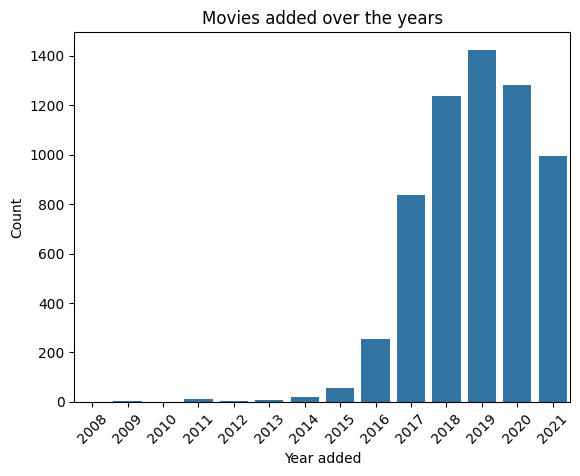

In [139]:
movies['year_added'].value_counts().sort_index()

sns.countplot(x='year_added', data=movies)
plt.title('Movies added over the years')
plt.xlabel('Year added')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Netflix added more movies rapidly after 2016

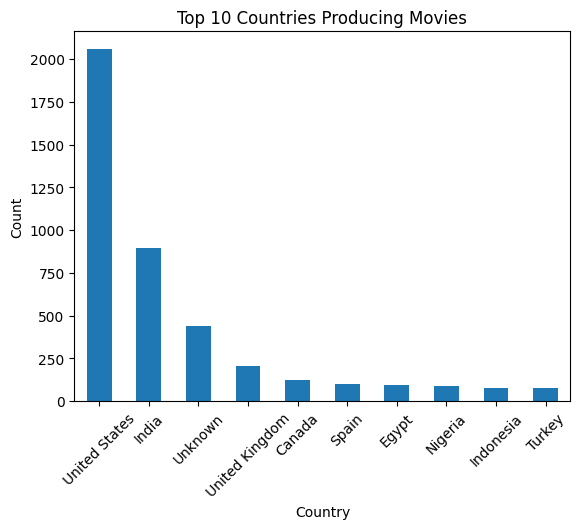

In [140]:
movies['country'].value_counts().head(10)
movies['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries Producing Movies")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

US produces the most number of movies

In [ ]:
movies['rating'].value_counts()

,count
rating,
TV-MA,2064
TV-14,1427
R,797
TV-PG,540
PG-13,490
PG,287
TV-Y7,139
TV-Y,131
TV-G,126


In [ ]:
# The last three rows of the rating count is the duration
movies[movies['rating'].str.contains('min', na=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,1 Season,Movies,"Louis C.K. muses on religion, eternal love, gi...",2017,4
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,1 Season,Movies,Emmy-winning comedy writer Louis C.K. brings h...,2016,9
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,1 Season,Movies,The comic puts his trademark hilarious/thought...,2016,8


In [ ]:
mask = movies['rating'].str.contains('min', na=False)
movies.loc[mask, 'duration'] = movies.loc[mask, 'rating']
movies.loc[mask, 'rating'] = None

movies['rating'] = movies['rating'].fillna(movies['rating'].mode()[0])

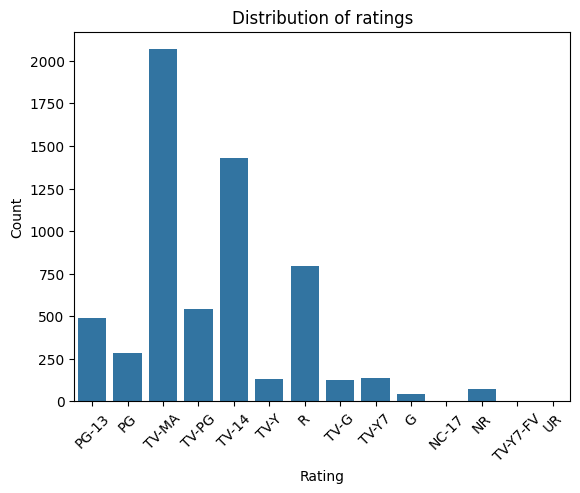

In [ ]:
sns.countplot(x='rating', data=movies)
plt.title('Distribution of ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Most movies are rated TV-MA, indicating mature content

In [ ]:
movies['duration'] = movies['duration'].str.replace(' min','')
movies['duration'] = movies['duration'].astype(int)

In [ ]:
movies['duration'].describe()

,duration
count,6131.000000
mean,99.564998
std,28.289504
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


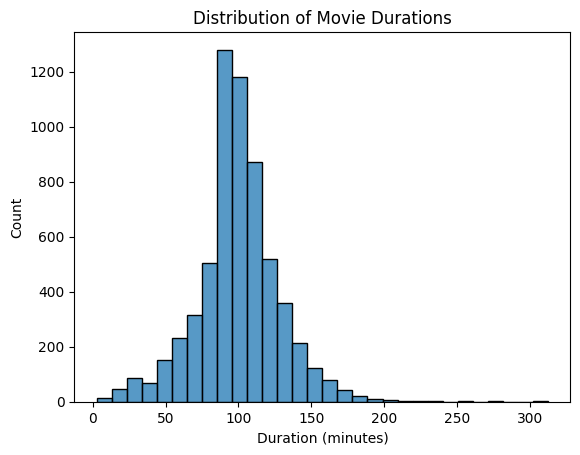

In [ ]:
sns.histplot(movies['duration'], bins=30)
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.show()

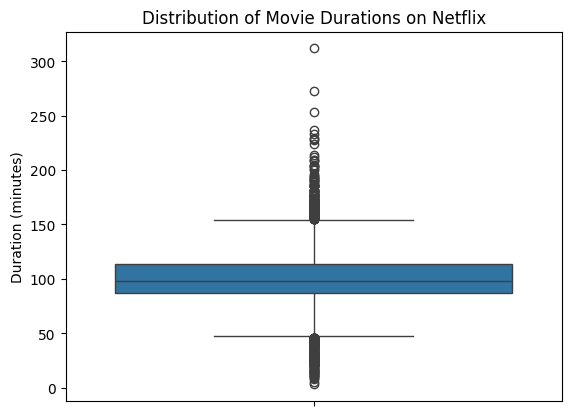

In [ ]:
sns.boxplot(y=movies['duration'])
plt.title("Distribution of Movie Durations on Netflix")
plt.ylabel("Duration (minutes)")
plt.show()

Most movies are within the 85 to 115 minutes time range

In [ ]:
movies.sort_values(by='duration', ascending=False).head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
4253,s4254,Movie,Black Mirror: Bandersnatch,Unknown,"Fionn Whitehead, Will Poulter, Craig Parkinson...",United States,2018-12-28,2018,TV-MA,312,"Dramas, International Movies, Sci-Fi & Fantasy","In 1984, a young programmer begins to question...",2018,12
717,s718,Movie,Headspace: Unwind Your Mind,Unknown,"Andy Puddicombe, Evelyn Lewis Prieto, Ginger D...",Unknown,2021-06-15,2021,TV-G,273,Documentaries,"Do you want to relax, meditate or sleep deeply...",2021,6
2491,s2492,Movie,The School of Mischief,Houssam El-Din Mustafa,"Suhair El-Babili, Adel Emam, Saeed Saleh, Youn...",Egypt,2020-05-21,1973,TV-14,253,"Comedies, Dramas, International Movies",A high school teacher volunteers to transform ...,2020,5


The Black Mirror is the longest movie with the duration of 312 minutes.

In [ ]:
movies['listed_in'].value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186
"Dramas, International Movies, Romantic Movies",180


In [ ]:
all_genres = movies['listed_in'] = movies['listed_in'].str.split(', ')

from itertools import chain
mflat_genres = list(chain.from_iterable(all_genres))
mgenre_counts = pd.Series(mflat_genres).value_counts()
mgenre_counts

,count
International Movies,2752
Dramas,2427
Comedies,1674
Documentaries,869
Action & Adventure,859
Independent Movies,756
Children & Family Movies,641
Romantic Movies,616
Thrillers,577
Music & Musicals,375


International Movies is the top genre

In [ ]:
movies['release_year'].value_counts().sort_index()

,count
release_year,
1942,2
1943,3
1944,3
1945,3
1946,1
...,...
2017,767
2018,767
2019,633


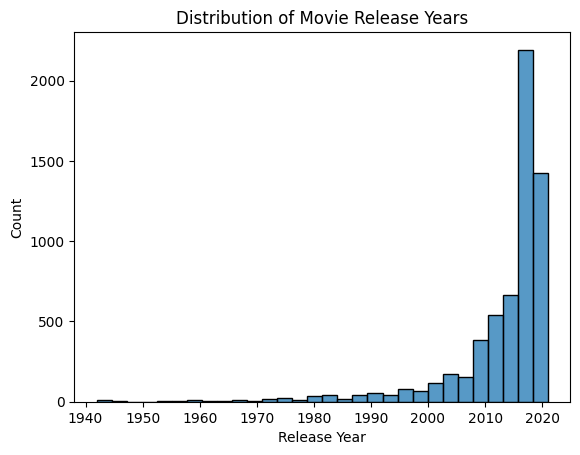

In [ ]:
sns.histplot(movies['release_year'], bins=30)
plt.title("Distribution of Movie Release Years")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.show()

In [ ]:
movies['release_year'].mean()

np.float64(2013.1215136193116)

On average, the movies were released around 2013.

In [ ]:
movies['year_added'].mean()

np.float64(2018.8492904909476)

On average, the movies were added to Netlfix around 2018, showing a delay in content addition

In [ ]:
movies.sort_values(by='release_year').head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
7790,s7791,Movie,Prelude to War,Frank Capra,Unknown,United States,2017-03-31,1942,TV-14,52,"Classic Movies, Documentaries",Frank Capra's documentary chronicles the rise ...,2017,3
8205,s8206,Movie,The Battle of Midway,John Ford,"Henry Fonda, Jane Darwell",United States,2017-03-31,1942,TV-14,18,"Classic Movies, Documentaries",Director John Ford captures combat footage of ...,2017,3
8660,s8661,Movie,Undercover: How to Operate Behind Enemy Lines,John Ford,Unknown,United States,2017-03-31,1943,TV-PG,61,"Classic Movies, Documentaries",This World War II-era training film dramatizes...,2017,3


The oldest movies produced were from 1942 and were added to Netflix in March 2017

**Key Findings from Movies**
1.   There are 6131 movies available.
2.   More movies were added after 2016.
3.   United States produced the most movies.
4.   TV-MA is the most common rating.
5.   Most movies range from 85-115 minutes.








2.   Going through TV shows



In [ ]:
tvshows = df[df['type'] == 'TV Show']
tvshows = tvshows.copy()
tvshows

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,Unknown,"Mike Liscio, Emily Bauer, Billy Bob Thompson, ...","Japan, Canada",2018-05-01,2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV",Now that he's discovered the Pendulum Summonin...,2018,5
8796,s8797,TV Show,Yunus Emre,Unknown,"Gökhan Atalay, Payidar Tüfekçioglu, Baran Akbu...",Turkey,2017-01-17,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves...",2017,1
8797,s8798,TV Show,Zak Storm,Unknown,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia",2018-09-13,2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...,2018,9
8800,s8801,TV Show,Zindagi Gulzar Hai,Unknown,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,2016-12-15,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre...",2016,12


There are 2666 tv shows.

In [ ]:
tvshows.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


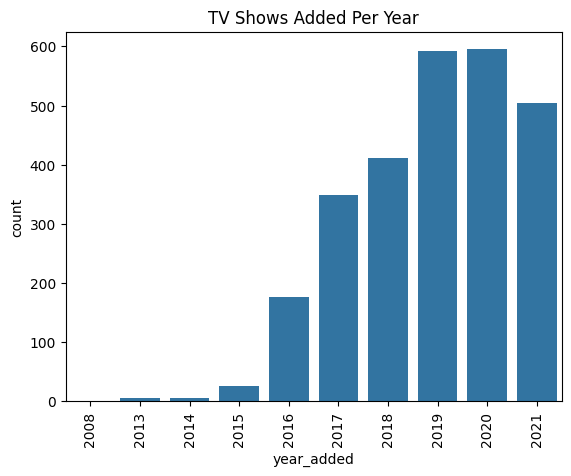

In [ ]:
sns.countplot(x='year_added', data=tvshows)
plt.title("TV Shows Added Per Year")
plt.xticks(rotation=90)
plt.show()

In [ ]:
tvshows['country'].value_counts().head(10)

,count
country,
United States,754
Unknown,390
United Kingdom,212
Japan,168
South Korea,158
India,79
Taiwan,68
Canada,59
France,49


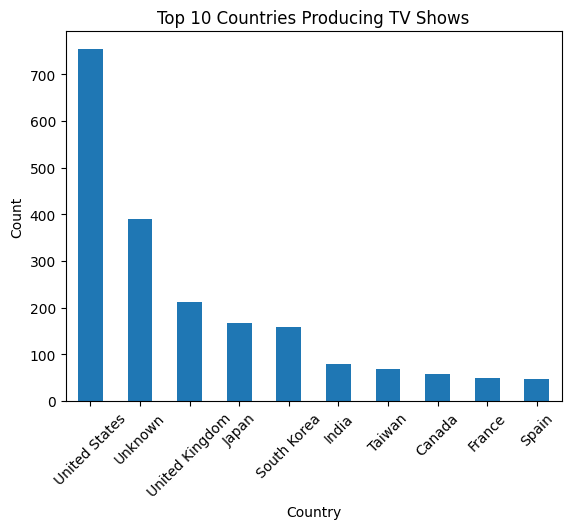

In [141]:
tvshows['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries Producing TV Shows")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
tvshows['rating'].value_counts()

,count
rating,
TV-MA,1145
TV-14,730
TV-PG,321
TV-Y7,194
TV-Y,175
TV-G,94
NR,4
R,2
TV-Y7-FV,1


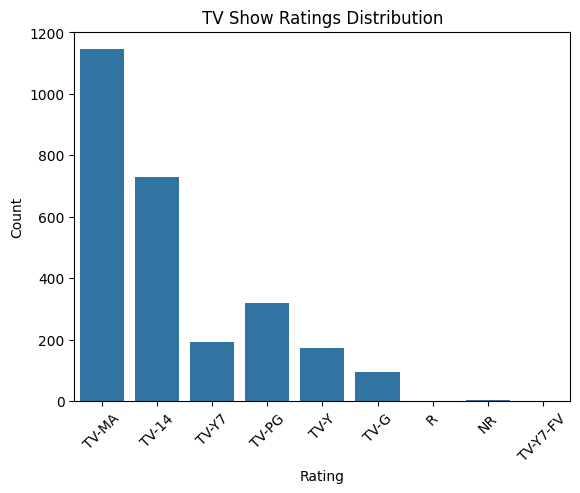

In [ ]:
sns.countplot(x='rating', data=tvshows)
plt.xticks(rotation=45)
plt.title("TV Show Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [142]:
tvshows['release_year'].value_counts().sort_index()

,count
release_year,
1925,1
1945,1
1946,1
1963,1
1967,1
1972,1
1974,1
1977,1
1979,1


In [144]:
tvshows.sort_values(by='release_year', ascending=True)[['title','release_year','year_added','country']].head(10)

,title,release_year,year_added,country
4250,Pioneers: First Women Filmmakers*,1925,2018,Unknown
1331,Five Came Back: The Reference Films,1945,2021,United States
7743,Pioneers of African-American Cinema,1946,2017,United States
8541,The Twilight Zone (Original Series),1963,2017,United States
8189,The Andy Griffith Show,1967,2017,United States
4550,Monty Python's Fliegender Zirkus,1972,2018,"United Kingdom, West Germany"
4551,Monty Python's Flying Circus,1974,2018,United Kingdom
6549,Dad's Army,1977,2018,United Kingdom
6674,El Chavo,1979,2017,Mexico
7588,Ninja Hattori,1981,2018,Japan


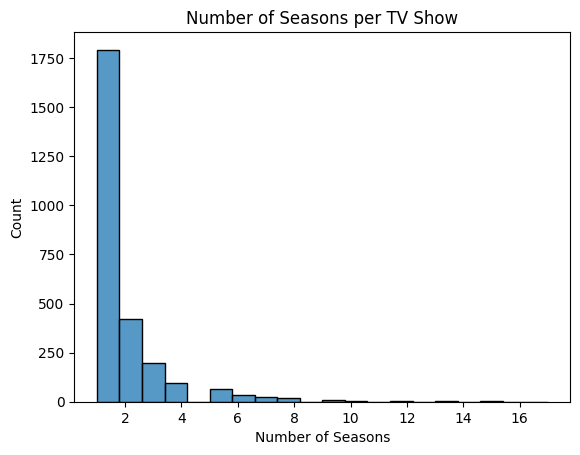

In [ ]:
tvshows['seasons'] = tvshows['duration'].str.replace(' Season','').str.replace('s','').astype(int)
sns.histplot(tvshows['seasons'], bins=20)
plt.title("Number of Seasons per TV Show")
plt.xlabel("Number of Seasons")
plt.ylabel("Count")
plt.show()

In [ ]:
tvshows['listed_in'].value_counts().head(10)

,count
listed_in,
Kids' TV,219
"International TV Shows, TV Dramas",121
"Crime TV Shows, International TV Shows, TV Dramas",110
"Kids' TV, TV Comedies",98
Reality TV,95
"International TV Shows, Romantic TV Shows, TV Comedies",94
"International TV Shows, Romantic TV Shows, TV Dramas",90
"Anime Series, International TV Shows",88
Docuseries,84


In [ ]:
all_genres = tvshows['listed_in'] = tvshows['listed_in'].str.split(', ')

from itertools import chain
flat_genres = list(chain.from_iterable(all_genres))
genre_counts = pd.Series(flat_genres).value_counts()
genre_counts

,count
International TV Shows,1350
TV Dramas,762
TV Comedies,574
Crime TV Shows,469
Kids' TV,449
Docuseries,394
Romantic TV Shows,370
Reality TV,255
British TV Shows,252
Anime Series,175


International TV shows is the highest genre

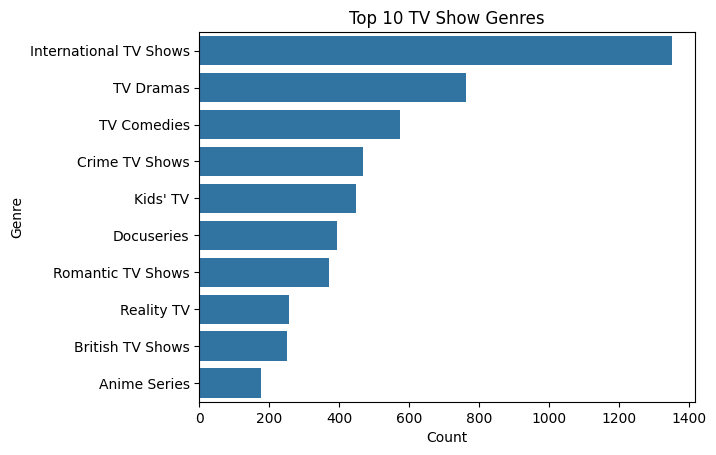

In [ ]:
top10_genres = genre_counts.head(10)
sns.barplot(x=top10_genres.values, y=top10_genres.index)
plt.title("Top 10 TV Show Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

**Key Insights from TV Shows**

1. Most TV shows were added from 2016.
2. TV-MA is the most common rating.
3. The US produces the most TV shows.
4. Most shows have 1-3 seasons.
5. International TV Shows dominate genres.

**Visualizations**

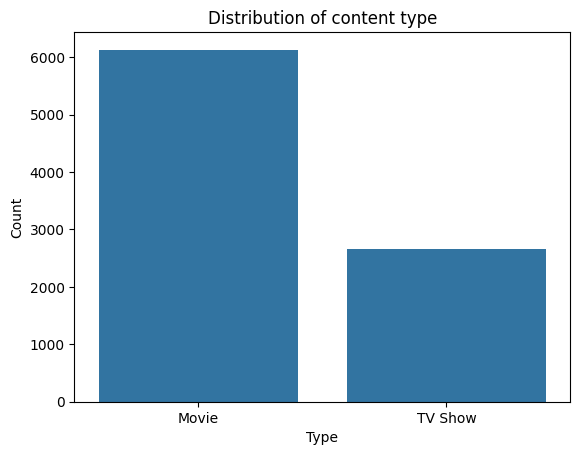

In [ ]:
sns.countplot(x='type', data=df)
plt.title('Distribution of content type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

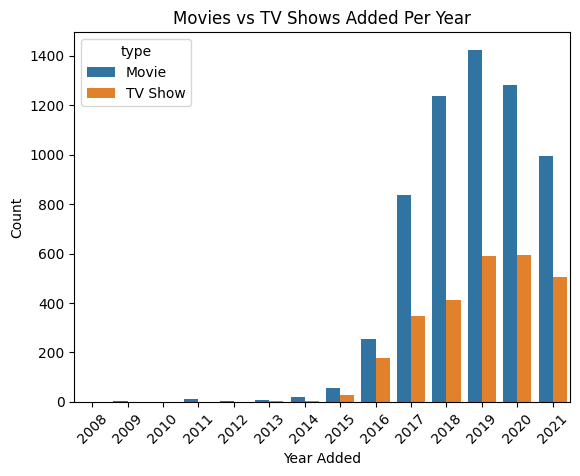

In [ ]:
sns.countplot(x='year_added', hue='type', data=df)
plt.xticks(rotation=45)
plt.title("Movies vs TV Shows Added Per Year")
plt.xlabel("Year Added")
plt.ylabel("Count")
plt.show()

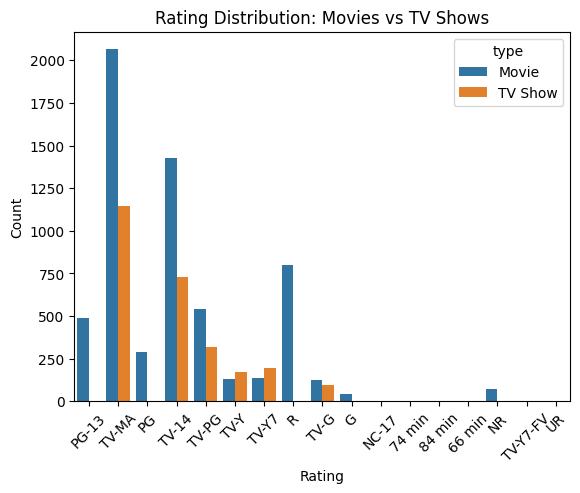

In [ ]:
sns.countplot(x='rating', hue='type', data=df)
plt.xticks(rotation=45)
plt.title("Rating Distribution: Movies vs TV Shows")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [ ]:
df.groupby('type')['country'].value_counts().groupby(level=0).head(5)

type     country       
Movie    United States     2058
         India              893
         Unknown            440
         United Kingdom     206
         Canada             122
TV Show  United States      754
         Unknown            390
         United Kingdom     212
         Japan              168
         South Korea        158
Name: count, dtype: int64

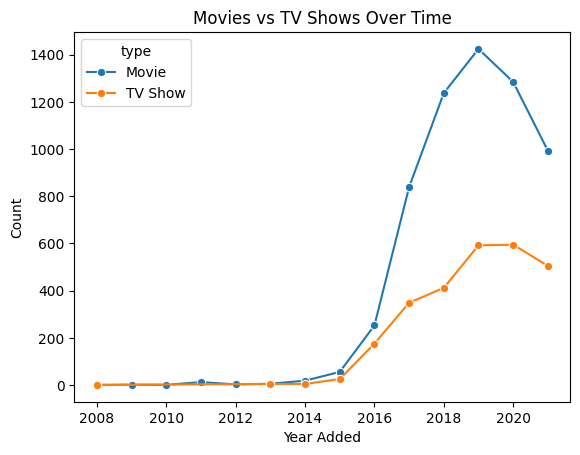

In [145]:
year_type = df.groupby(['year_added', 'type']).size().reset_index(name='count')

sns.lineplot(data=year_type, x='year_added', y='count', hue='type', marker='o')
plt.title('Movies vs TV Shows Over Time')
plt.xlabel('Year Added')
plt.ylabel('Count')
plt.show()

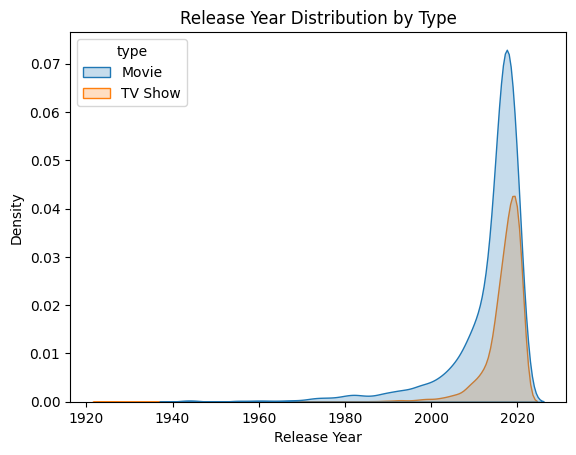

In [147]:
sns.kdeplot(data=df, x='release_year', hue='type', fill=True)

plt.title("Release Year Distribution by Type")
plt.xlabel("Release Year")
plt.show()

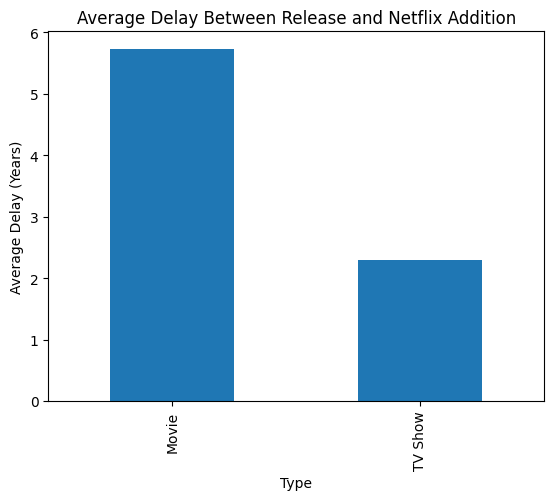

In [ ]:
df['delay'] = df['year_added'] - df['release_year']
df.groupby('type')['delay'].mean().plot(kind='bar')

plt.title("Average Delay Between Release and Netflix Addition")
plt.xlabel("Type")
plt.ylabel("Average Delay (Years)")
plt.show()

* Movies generally experience a longer delay before appearing on Netflix.
* TV shows tend to be added closer to their original release year.